# CONAF Bosque Nativo awards — extract, clean & visualise (cl-conaf-bn-awards, v1)

Source: `sample/extract.xlsx` — hand-exported from concursolbn.conaf.cl, 10 annual cycles (Primer Concurso 2016–2025) of the Fondo de Conservación, Recuperación y Manejo Sustentable del Bosque Nativo (Ley 20.283).
Review README: `../../README.md` · Need: `2026-06-cl-finance-opportunities`.
Purpose: produce a **de-identified, pipeline-ready** project table (all PII dropped) + render the **aggregates as charts inline** (not saved as image files; the precise figures live as tables in `review.md`). Restart-and-run-all must pass before commit.

In [1]:
import pandas as pd, numpy as np, hashlib, os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
RAW, DATA = "sample/extract.xlsx", "data"
os.makedirs(DATA, exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.titlesize":11,"axes.titleweight":"bold",
    "axes.spines.top":False,"axes.spines.right":False,"axes.grid":True,"grid.alpha":.25,"axes.axisbelow":True})
GREEN, MUTED = "#2e7d52", ["#2e7d52","#7cb342","#bfbf6f","#c9c9c9"]
print("raw exists:", os.path.exists(RAW), "| size MB:", round(os.path.getsize(RAW)/1e6,2))

raw exists: True | size MB: 1.55


## 1. Load raw — zero transformations
Parsing note (README): row 0 is blank, header is on row 1, data from row 2. `header=1` handles it.

In [2]:
raw = pd.read_excel(RAW, sheet_name="Worksheet", header=1, dtype=str).dropna(how="all")
print(raw.shape); raw.head(2)

(9860, 36)


,rptpro_id,rptpro_numero_ingreso,rptpro_puntaje,rptpro_superficie,rptpro_tipo_concurso,rptpro_objetivo_manejo,rptpro_tipo_postulacion,rptpro_tipo_presentacion,rptpro_fecha_presentacion,rptpro_ano,...,rptpro_superficie_plan,rptpro_bono_saff,rptpro_superficie_bonos,rptpro_monto_asesoria_total,rptpro_monto_asistencia_tecnica,rptpro_monto_elaboracion_plan,rptpro_monto_informe_ejecucion,rptpro_bono_segun_saff,rptpro_plan_segun_saff,rptpro_email_presenta
0,1249829,052/2018,56.58,2.5,Pequeños Propietarios,PRODUCCION MADERERA,Individual,Digital,2018-02-28,2018,...,2.5,861/221-5/12,2.5,NaN,NaN,NaN,NaN,201/221-104/18,NaN,pquellon@gmail.com
1,1257922,486/2018,51.86,2.68,Pequeños Propietarios,PRODUCCION MADERERA,Individual,Digital,2018-05-14,2018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11/221-921/19,NaN,leonardo.balbontin@conaf.cl


## 2. Clean — de-identify (DROP all personal data)
Parsing note: presenter name + email are personal data → dropped completely. `rptpro_tipo_presenta` (presenter *type*) is non-identifying and kept.

In [3]:
PII = ["rptpro_presentado_por", "rptpro_email_presenta"]
df = raw.drop(columns=[col for c0 in PII for col in raw.columns if col.startswith(c0)])
assert not any(("email" in c.lower() or "presentado" in c.lower()) for c in df.columns), "PII column survived"
print("dropped:", PII, "| remaining cols:", len(df.columns))

dropped: ['rptpro_presentado_por', 'rptpro_email_presenta'] | remaining cols: 34


## 3. Clean — rename, type, derive
Parsing note: rename by EXACT name (prefixes like `rptpro_superficie*` / `rptpro_tipo_presenta*` collide). monto/aporte are **UTM** → `_utm`; add region short-name; cast numerics/dates.

In [4]:
REG = {1:"Tarapacá",2:"Antofagasta",3:"Atacama",4:"Coquimbo",5:"Valparaíso",6:"O'Higgins",
       7:"Maule",8:"Biobío",9:"La Araucanía",10:"Los Lagos",11:"Aysén",12:"Magallanes",
       13:"Metropolitana",14:"Los Ríos",15:"Arica y Parinacota",16:"Ñuble"}
ren = {"rptpro_id":"award_id","rptpro_numero_ingreso":"numero_ingreso","rptpro_ano":"ano",
 "rptpro_id_concurso":"concurso_id","rptpro_nombre_concurso":"concurso","rptpro_fecha_presentacion":"fecha_presentacion",
 "rptpro_tipo_concurso":"tipo_concurso","rptpro_objetivo_manejo":"objetivo_manejo","rptpro_literal":"literal",
 "rptpro_numero_region":"region_num","rptpro_puntaje":"puntaje","rptpro_superficie":"superficie_ha",
 "rptpro_tipo_presenta":"presenter_type",
 "rptpro_monto_total":"monto_total_utm","rptpro_monto_actividades":"monto_actividades_utm",
 "rptpro_monto_ordenacion":"monto_ordenacion_utm","rptpro_aporte":"aporte_propietario_utm",
 "rptpro_monto_asesoria_total":"monto_asesoria_utm","rptpro_monto_asistencia_tecnica":"monto_asistencia_tecnica_utm",
 "rptpro_monto_elaboracion_plan":"monto_elaboracion_plan_utm","rptpro_monto_informe_ejecucion":"monto_informe_ejecucion_utm",
 "rptpro_tiene_plan_saff":"tiene_plan_saff","rptpro_tiene_bonificacion_saff":"tiene_bonificacion_saff",
 "rptpro_numero_bonos":"numero_bonos"}
missing=[k for k in ren if k not in df.columns]; assert not missing, f"missing source cols: {missing}"
df = df.rename(columns=ren)[list(ren.values())].copy()
df["region_num"]=pd.to_numeric(df["region_num"],errors="coerce").astype("Int64")
df.insert(df.columns.get_loc("region_num")+1,"region",df["region_num"].map(REG))
df["ano"]=pd.to_numeric(df["ano"],errors="coerce").astype("Int64")
df["fecha_presentacion"]=pd.to_datetime(df["fecha_presentacion"],errors="coerce")
for col in [x for x in df.columns if x.endswith("_utm") or x in ("puntaje","superficie_ha","numero_bonos")]:
    df[col]=pd.to_numeric(df[col],errors="coerce")
print("rows:",len(df),"| cols:",len(df.columns)); df.head(2)

rows: 9860 | cols: 25


,award_id,numero_ingreso,ano,concurso_id,concurso,fecha_presentacion,tipo_concurso,objetivo_manejo,literal,region_num,...,monto_actividades_utm,monto_ordenacion_utm,aporte_propietario_utm,monto_asesoria_utm,monto_asistencia_tecnica_utm,monto_elaboracion_plan_utm,monto_informe_ejecucion_utm,tiene_plan_saff,tiene_bonificacion_saff,numero_bonos
0,1249829,052/2018,2018,1248949,Primer Concurso 2018,2018-02-28,Pequeños Propietarios,PRODUCCION MADERERA,C,10,...,28.76,0.0,0.0,NaN,NaN,NaN,NaN,1,Si,1.0
1,1257922,486/2018,2018,1248949,Primer Concurso 2018,2018-05-14,Pequeños Propietarios,PRODUCCION MADERERA,C,9,...,24.25,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Si,NaN


## 4. Validate — assertions (no export if any fail)

In [5]:
exp={2016:1073,2017:1034,2018:1042,2019:1087,2020:1091,2021:912,2022:955,2023:870,2024:990,2025:806}
assert {int(k):int(v) for k,v in df["ano"].value_counts().items()}==exp
assert len(df)==9860 and df["award_id"].is_unique and df["concurso_id"].nunique()==10
yt=df.groupby("ano")["monto_total_utm"].sum(); assert yt.between(80000,130000).all(), yt
assert not any(("email" in c.lower() or "presentado" in c.lower() or "rut" in c.lower()) for c in df.columns)
print("ALL ASSERTIONS PASSED")

ALL ASSERTIONS PASSED


## 5. Export — ONE tidy, de-identified, pipeline-ready table to data/
Aggregates are **not** written to CSV — they are rendered as charts below (§7).

In [6]:
proj=f"{DATA}/cl_conaf_bn_awards_projects.csv"; df.to_csv(proj,index=False)
print(round(os.path.getsize(proj)/1024,1),"KB", proj)
print("SHA256:", hashlib.sha256(open(proj,'rb').read()).hexdigest()[:16])

2096.3 KB data/cl_conaf_bn_awards_projects.csv
SHA256: 774a18b1e1146412


## 6. Aggregates (in-memory) — built for charting, not exported

In [7]:
by_year=df.groupby("ano").agg(n_awards=("award_id","size"),utm=("monto_total_utm","sum"),
        med_award=("monto_total_utm","median")).reset_index()
by_region=(df["region"].value_counts()).rename_axis("region").reset_index(name="n")
comp=(df.pivot_table(index="ano",columns="objetivo_manejo",values="award_id",aggfunc="size",fill_value=0))
comp_sh=comp.div(comp.sum(1),axis=0)*100
df["utm_per_ha"]=df["monto_total_utm"]/df["superficie_ha"]
exec_by_cohort=(df.assign(b=df["tiene_bonificacion_saff"].eq("Si")).groupby("ano")["b"].mean()*100)
by_year

,ano,n_awards,utm,med_award
0,2016,1073,96752.76,37.300
1,2017,1034,94180.10,46.005
2,2018,1042,92598.14,46.405
3,2019,1087,89953.47,41.410
4,2020,1091,114866.06,50.000
5,2021,912,114214.46,56.450
6,2022,955,112323.80,54.050
7,2023,870,105761.06,53.795
8,2024,990,104248.32,50.660
9,2025,806,103658.19,58.280


## 7. Visualise aggregates inline (the deliverable, in place of aggregate CSVs)

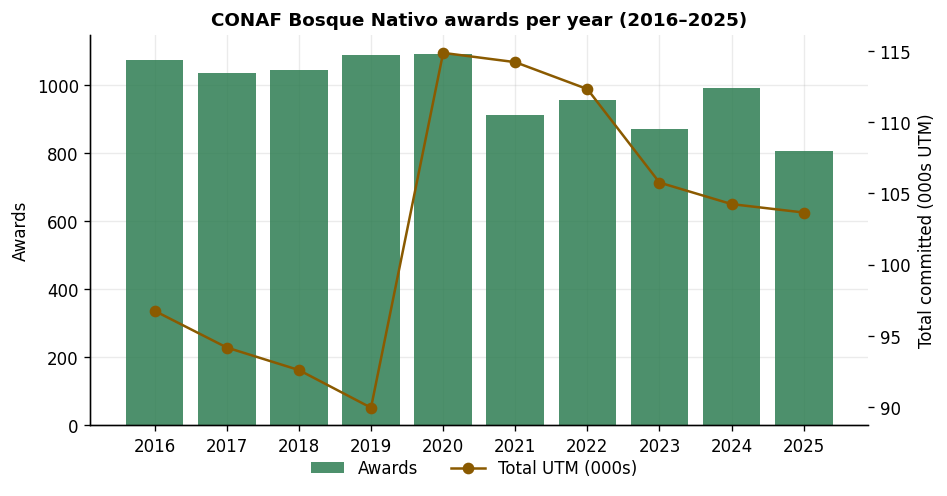

In [8]:
# 7.1 Demand over time: awards/yr (bars) + total UTM (line)
fig,ax=plt.subplots(figsize=(8,4))
ax.bar(by_year["ano"],by_year["n_awards"],color=GREEN,alpha=.85,label="Awards")
ax.set_ylabel("Awards"); ax.set_xlabel(""); ax.set_title("CONAF Bosque Nativo awards per year (2016–2025)")
ax2=ax.twinx(); ax2.plot(by_year["ano"],by_year["utm"]/1000,color="#8a5a00",marker="o",label="Total UTM (000s)")
ax2.set_ylabel("Total committed (000s UTM)"); ax2.grid(False)
ax.set_xticks(by_year["ano"])
fig.legend(loc="lower center",ncol=2,frameon=False,bbox_to_anchor=(.5,-.04)); fig.tight_layout()
plt.show()

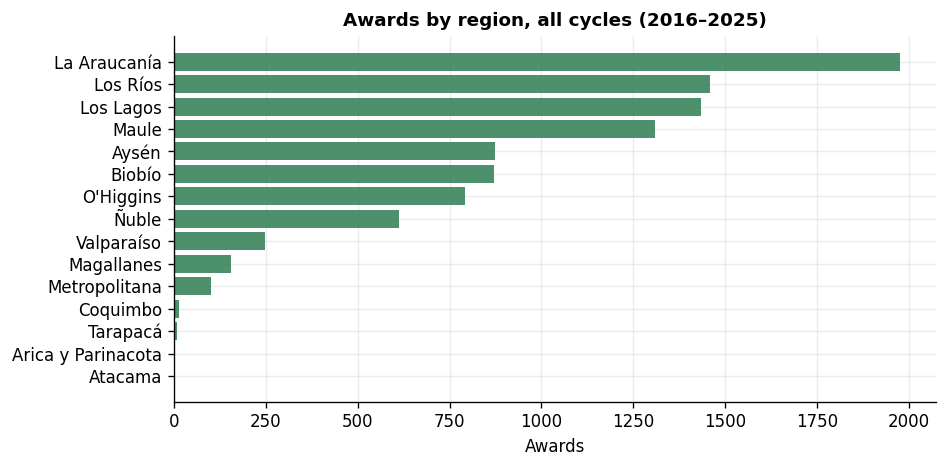

In [9]:
# 7.2 Geographic concentration
fig,ax=plt.subplots(figsize=(8,4))
d=by_region.sort_values("n")
ax.barh(d["region"],d["n"],color=GREEN,alpha=.85)
ax.set_title("Awards by region, all cycles (2016–2025)"); ax.set_xlabel("Awards")
fig.tight_layout(); plt.show()

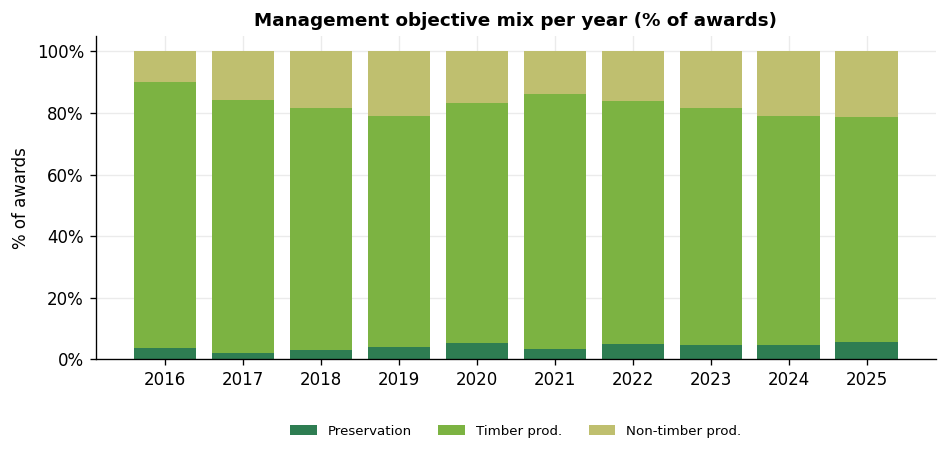

In [10]:
# 7.3 Composition over time (objetivo de manejo, % share)
fig,ax=plt.subplots(figsize=(8,4))
bottom=np.zeros(len(comp_sh)); 
labels={"PRODUCCION MADERERA":"Timber prod.","PRODUCCION NO MADERERA":"Non-timber prod.",
        "BOSQUE PRESERVACION Y FORMACIONES XEROFITICAS DE ALTO VALOR ECOLOGICO":"Preservation"}
for i,col in enumerate(comp_sh.columns):
    ax.bar(comp_sh.index,comp_sh[col],bottom=bottom,label=labels.get(col,col)[:18],color=MUTED[i%len(MUTED)])
    bottom+=comp_sh[col].values
ax.set_title("Management objective mix per year (% of awards)"); ax.set_ylabel("% of awards"); ax.set_xticks(comp_sh.index)
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.legend(frameon=False,fontsize=8,loc="lower center",ncol=3,bbox_to_anchor=(.5,-.28))
fig.tight_layout(); plt.show()

/sessions/confident-keen-mayer/tmp/ipykernel_8/533736161.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp=ax.boxplot(data,labels=["A preservation","B non-timber","C timber"],showfliers=False,patch_artist=True)


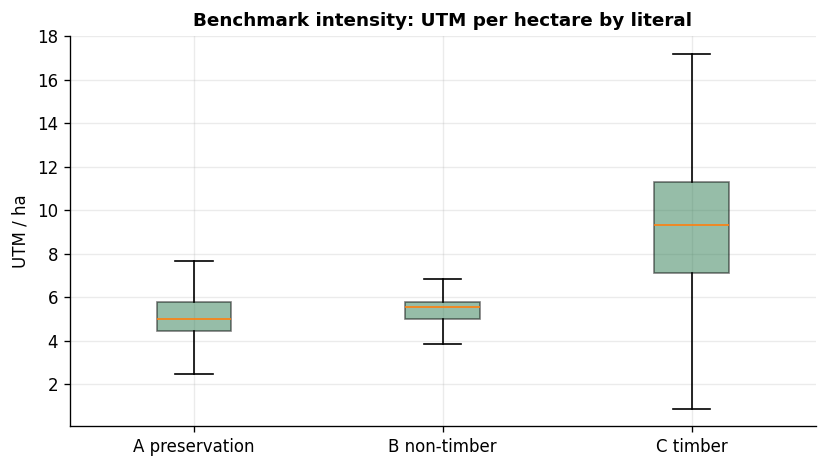

In [11]:
# 7.4 Award-size benchmark: UTM per hectare by literal (boxplot, outliers trimmed for view)
fig,ax=plt.subplots(figsize=(7,4))
data=[df.loc[(df["literal"]==L)&(df["utm_per_ha"]<30),"utm_per_ha"].dropna() for L in ["A","B","C"]]
bp=ax.boxplot(data,labels=["A preservation","B non-timber","C timber"],showfliers=False,patch_artist=True)
for p in bp["boxes"]: p.set(facecolor=GREEN,alpha=.5)
ax.set_title("Benchmark intensity: UTM per hectare by literal"); ax.set_ylabel("UTM / ha")
fig.tight_layout(); plt.show()

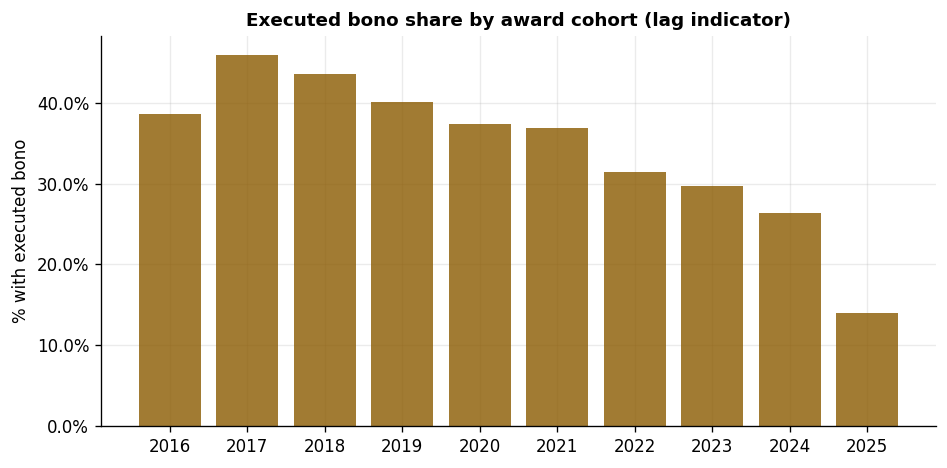

In [12]:
# 7.5 Award→payment lag: executed-bono share by cohort year
fig,ax=plt.subplots(figsize=(8,4))
ax.bar(exec_by_cohort.index,exec_by_cohort.values,color="#8a5a00",alpha=.8)
ax.set_title("Executed bono share by award cohort (lag indicator)"); ax.set_ylabel("% with executed bono")
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.set_xticks(exec_by_cohort.index)
fig.tight_layout(); plt.show()

## 8. Findings

- **9,860 awards across 10 annual cycles (2016–2025)**; counts match published per-year totals; `award_id` unique.
- **Amounts are UTM, confirmed every year** (annual totals 90k–115k UTM, about CLP 6.7–7 bn fund).
- **One pipeline CSV** (`data/cl_conaf_bn_awards_projects.csv`); **aggregates are charts rendered inline** (not saved as files), with the precise figures as tables in `review.md`. Clearer for a reader and regenerated on every run.
- **PII dropped at load**; only non-identifying `presenter_type` kept. No personal data in committed outputs.
- Charts confirm the decade-stable story: durable demand, south-central concentration, around 79% timber skew, per-ha intensities tracking the legal caps, and a clear award-to-payment lag (older cohorts around 40% executed vs 14% for 2025).